In [1]:
def find_closest_snp(snp, source_data):
    idx = df_pos_raw.index
    pos = idx.get_indexer([snp], method='nearest')[0]

    snp_approx = idx[pos]

    return int(snp_approx)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sys
import importlib

import os
os.environ['CUDA_PATH'] = '/apps/compilers/cuda/13.2.1' 

import torch
print(f"number of available GPUs = {torch.cuda.device_count()}")
output_device = 'cpu'

import vcme
from vcme.functions import prepare_proteingym_data
from vcme.utils import yeast_data, clear_gpu_mem, reload_obj, get_pathway_info
from vcme.utils import tensor_scatter, read_marginal_results, get_gene_interval


from epik.utils import encode_seqs, split_training_test

import epikVC
from epikVC.models import GPModel

number of available GPUs = 1


In [3]:
fig_path = '../figures/'
result_path = '../results/yeast_analysis/'

In [4]:
geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
pheno_path = "/orange/juannanzhou/dryad_data/"
pheno_name = '37C'

from vcme.utils import YeastMetadata

snp_info_path = "../data/yeast/snp_info_final.csv"
pathway_info_path = "/blue/juannanzhou/fahimeh.rahimi/Marginal_Epistasis/yeast_pathway_gene_tables/all_pathway_gene_tables.tsv"

genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)

number of pathways = 123
number of genes in pathways = 355


In [5]:
import vcme.utils
importlib.reload(vcme.utils)
from vcme.utils import make_man, make_df_plot, plot_track

snp_info = genomic_meta_data.snp_info
gene_info = genomic_meta_data.gene_info

In [6]:
dfs = [pd.read_csv(f"../results/yeast_analysis/beaver_dam_k=2_sample_{i}.csv", index_col=0) for i in range(100)]
df_pos_raw = pd.concat(dfs, axis=1)

dfs = [pd.read_csv(f"../results/yeast_analysis/beaver_dam_k=2_sample_{i}_percent.csv", index_col=0) for i in range(100)]
df_pos_percent = pd.concat(dfs, axis=1)

Converting to pd df
rescale vc to percentage


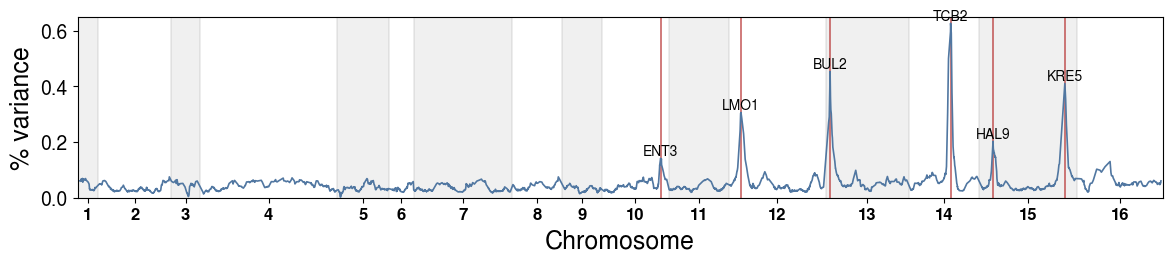

In [7]:
plot_df = df_pos_percent.iloc[:, 0]
y_threshold = 100 * plot_df.quantile(.98)

ax = make_man(plot_df, genomic_meta_data.snp_info, y_threshold, ylab='% variance', label_genes=True, ylim=[0, 0.65])
plt.show()

In [39]:
from vcme.utils import make_df_plot

plot_df_map = df_pos_percent.iloc[:, 0]
y_threshold = 100 * plot_df_map.quantile(.98)

_, df_plot_max = make_df_plot(plot_df_map, snp_info, y_threshold)

snps_to_show = df_plot_max.index

df_pos_percent__ = 2 * df_pos_raw/df_pos_raw.iloc[:, 0].sum()

df_pos_percent_to_show = df_pos_percent__.loc[snps_to_show]

df_pos_percent_to_show.index = list(df_plot_max.gene)

df_pos_percent_to_show.index = ['VPS70', 'LMO1', 'BUL2', 'MKT1', 'HAL9', 'MIP1']

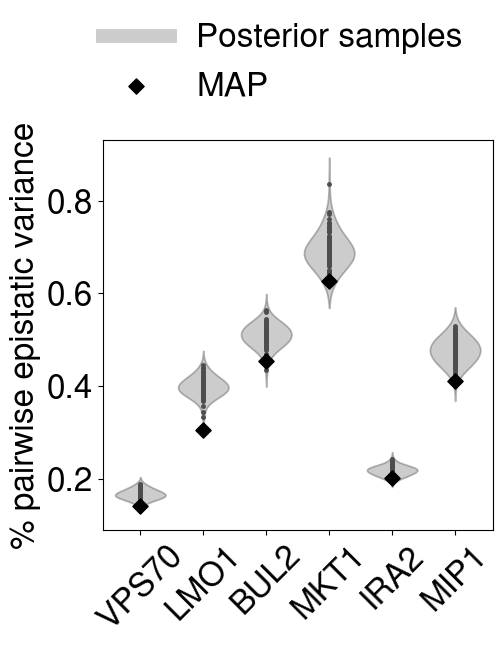

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update(
    {
        "font.size": 24,
        "font.family": "sans-serif",
        "font.sans-serif": ["Nimbus Sans"],
    }
)

df = df_pos_percent_to_show
num_stats = len(df)

# The canvas is 6 × 6 inches.
fig, ax = plt.subplots(figsize=(7, 7))

for x_pos, (stat_name, row_data) in enumerate(df.iterrows()):
    post_mean = 100 * row_data.iloc[0]
    post_samples = 100 * row_data.iloc[1:]

    # Plot the posterior distribution.
    sns.violinplot(
        y=post_samples,
        x=[x_pos] * len(post_samples),
        color="gray",
        alpha=0.4,
        bw_adjust=2,
        inner="points",
        ax=ax,
    )

    # Add a proxy artist for the posterior-samples legend entry.
    if x_pos == 0:
        ax.plot(
            [],
            [],
            color="gray",
            alpha=0.4,
            linewidth=10,
            label="Posterior samples",
        )

    # Plot the MAP estimate.
    ax.scatter(
        x_pos,
        post_mean,
        color="black",
        s=60,
        marker="D",
        zorder=3,
        label="MAP" if x_pos == 0 else None,
    )

ax.set_xticks(
    ticks=range(num_stats),
    labels=df.index,
    rotation=45,
    ha="center",
)

ax.set_xlim(-0.6, num_stats - 0.4)
ax.set_ylabel("% pairwise epistatic variance")

ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.02),
    frameon=False,
)

# Force the plotting area—not just the overall canvas—to be exactly square.
ax.set_box_aspect(1)

fig.tight_layout()

fig.savefig(
    "../figures/yeast/snp_posterior_k=2.pdf",
    format="pdf",
)

plt.show()